# Lecture 04 — Equipment sensor anomalies

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc AI and Machine Learning · Gulf College  
**Lecture:** 04 — Introduction to Machine Learning and Data Mining  
**Topic:** Anomaly detection · **Learning outcome emphasis:** MLO1 and MLO3 (with MLO4 preparation through technique selection)

## Learning objective
Explore unusual sensor readings as potential maintenance alerts.

## Practical problem
A fictional machine emits temperature, vibration, pressure and operating-hour readings.

## Dataset and transparency
The file **`dataset.csv`** was simulated for teaching. It is not collected from real people, businesses, medical systems or physical devices. Names/values are illustrative; models must not be deployed or used for real eligibility, employment, financial, clinical or safety decisions. A fixed random seed makes the example reproducible.

**How to run:** keep this notebook and `dataset.csv` in the same folder, then run all cells from top to bottom. If needed, install the packages listed in the collection’s `requirements.txt`.

**Assumptions:** The synthetic anomalies were planted; anomalies may be harmless or indicate a fault only after engineering investigation.

## 1. Load the dataset and understand the variables
Always inspect several rows, column names, types, and possible missing values before choosing a model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (7.2, 4.5), 'axes.grid': True, 'grid.alpha': .22})
DATA_FILE = Path('dataset.csv')
assert DATA_FILE.exists(), 'Place dataset.csv next to the notebook.'
df = pd.read_csv(DATA_FILE)
print(f'Dataset: {len(df):,} rows × {df.shape[1]} columns')
display(df.head())

Dataset: 830 rows × 5 columns


,temperature_c,vibration_mm_s,pressure_bar,operating_hours,is_anomaly
0,62.06,2.14,28.33,3314.4,0
1,63.37,2.64,27.46,2715.6,0
2,72.79,2.67,22.74,1192.8,0
3,77.20,2.92,28.31,3361.2,0
4,54.45,2.24,21.95,3895.7,0


In [2]:
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isna().sum().to_string())

Columns: ['temperature_c', 'vibration_mm_s', 'pressure_bar', 'operating_hours', 'is_anomaly']
Missing values per column:
temperature_c      0
vibration_mm_s     0
pressure_bar       0
operating_hours    0
is_anomaly         0


## 2. Explore typical versus unusual observations
The `is_anomaly` field was generated by the simulator as a **hidden evaluation label**. The unsupervised model must not fit on that field.

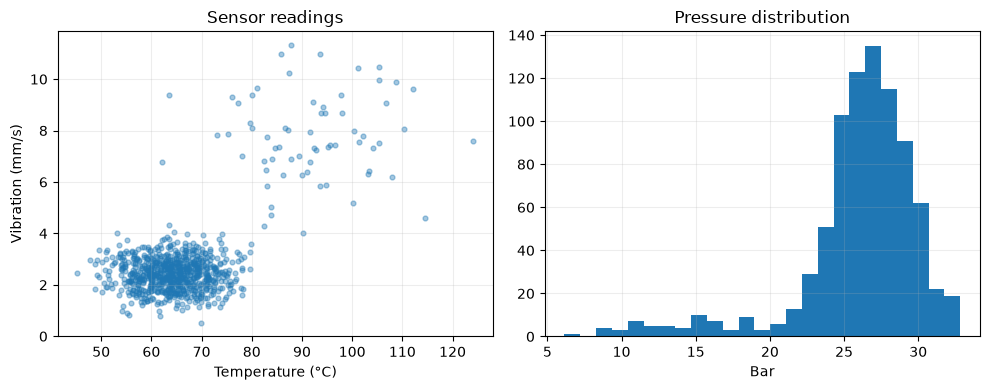

In [3]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].scatter(df['temperature_c'],df['vibration_mm_s'],s=12,alpha=.4)
ax[0].set(xlabel='Temperature (°C)',ylabel='Vibration (mm/s)',title='Sensor readings')
ax[1].hist(df['pressure_bar'],bins=25);ax[1].set(title='Pressure distribution',xlabel='Bar');plt.tight_layout();plt.show()

## 3. Fit an Isolation Forest
**Isolation Forest** isolates unusual points using random splits. Anomalies typically require fewer splits. `contamination` gives the expected fraction flagged, so choosing it affects false alarms.

In [4]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report,ConfusionMatrixDisplay
features=['temperature_c', 'vibration_mm_s', 'pressure_bar', 'operating_hours']
X=df[features]
scaler=StandardScaler();X_scaled=scaler.fit_transform(X)
model=IsolationForest(n_estimators=120,contamination=0.07,random_state=42)
model.fit(X_scaled) # No is_anomaly labels!
df['anomaly_prediction']=(model.predict(X_scaled)==-1).astype(int)
print('Flagged:',int(df['anomaly_prediction'].sum()),'of',len(df))

Flagged: 59 of 830


## 4. Evaluate against the **simulation-only** ground truth
Because the simulator created known anomaly labels, we can illustrate accuracy, precision, recall and a confusion matrix. In authentic unsupervised anomaly detection, reliable ground truth often does not exist and these metrics are unavailable.

Accuracy: 0.992
Precision (anomaly): 1.0
Recall (anomaly): 0.894
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       764
           1       1.00      0.89      0.94        66

    accuracy                           0.99       830
   macro avg       1.00      0.95      0.97       830
weighted avg       0.99      0.99      0.99       830



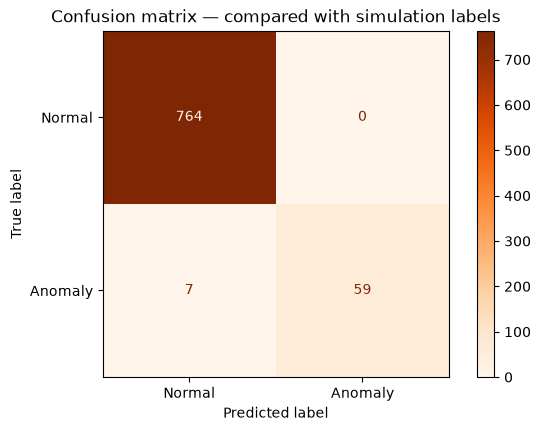

In [5]:
y_true=df['is_anomaly'];y_pred=df['anomaly_prediction']
print('Accuracy:',round(accuracy_score(y_true,y_pred),3))
print('Precision (anomaly):',round(precision_score(y_true,y_pred,zero_division=0),3))
print('Recall (anomaly):',round(recall_score(y_true,y_pred,zero_division=0),3))
print(classification_report(y_true,y_pred,zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_true,y_pred,display_labels=['Normal','Anomaly'],cmap='Oranges')
plt.title('Confusion matrix — compared with simulation labels');plt.grid(False);plt.show()

## 5. Show flagged anomalies and score new observations

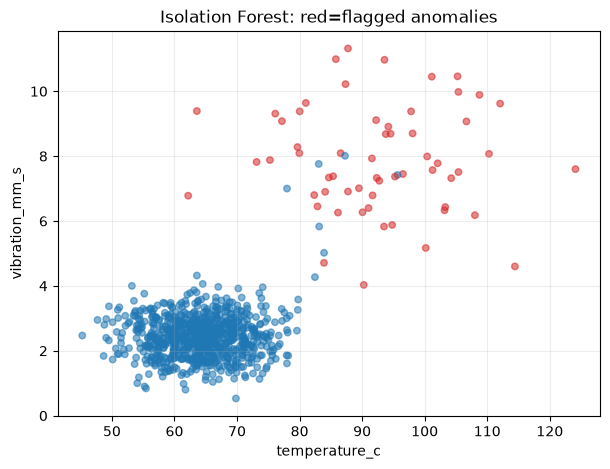

In [6]:
fig,ax=plt.subplots(figsize=(7,5))
colors=np.where(df['anomaly_prediction']==1,'tab:red','tab:blue')
ax.scatter(df[features[0]],df[features[1]],c=colors,alpha=.55,s=22)
ax.set(xlabel=features[0],ylabel=features[1],title='Isolation Forest: red=flagged anomalies');plt.show()

In [7]:
new=pd.DataFrame([{'temperature_c':62,'vibration_mm_s':2.3,'pressure_bar':27,'operating_hours':900},{'temperature_c':99,'vibration_mm_s':10,'pressure_bar':12,'operating_hours':3500}])
new['flagged']=(model.predict(scaler.transform(new[features]))==-1).astype(int)
display(new)

,temperature_c,vibration_mm_s,pressure_bar,operating_hours,flagged
0,62,2.3,27,900,0
1,99,10.0,12,3500,1


## Student investigation and discussion
1. Why should operating hours be scaled before modeling?
2. How would a maintenance engineer verify an anomaly alert?
3. What happens if all anomalies resemble the normal population?

**Reflect:** What assumption makes this classroom dataset easier than the equivalent real-world problem?

## References and further learning
- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
- Course connection: Lecture 04, OMC9000UK7, supervised/unsupervised learning, modelling workflow and evaluation.